# Baseline FOC Control for a Synchronous Reluctance Machine using Gym Electric Motor

This notebook implements a Field-Oriented Control strategy for a SynRM using the `Cont-SC-SynRM-v0` environment from Gym Electric Motor.

The baseline includes:

- Speed PI controller
- MTPA current reference generation
- Inner dq current PI controllers
- Voltage limitation
- dq-to-abc transformation
- Performance metrics for speed and current tracking

This notebook is used as the classical-control baseline before testing Deep Reinforcement Learning controllers.

In [ ]:
import gym_electric_motor as gem
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


PI

In [ ]:
class PIControlador:

    def __init__(self, kp, ki, limite, dt):
        self.kp      = kp
        self.ki      = ki
        self.limite  = limite
        self.dt      = dt
        self.integral = 0.0

    def reset(self):
        self.integral = 0.0  #Para reiniciar el controlador

    def calcular(self, setpoint, actual):
        error = setpoint - actual
        self.integral += error * self.dt

        #Anti windup
        if self.ki > 0:
            self.integral = np.clip(self.integral,
                                    -self.limite / self.ki,
                                     self.limite / self.ki)
        return float(np.clip(self.kp*error + self.ki*self.integral,
                             -self.limite, self.limite))

TRANSFORMADAS

In [ ]:
def park_inv(vd, vq, theta):
    return (vd*np.cos(theta) - vq*np.sin(theta),
            vd*np.sin(theta) + vq*np.cos(theta))

def clarke_inv(va, vb):
    return (va, -0.5*va + (np.sqrt(3)/2)*vb, -0.5*va - (np.sqrt(3)/2)*vb)

def dq_a_gem(vd, vq, theta_e, V_max):
    va, vb     = park_inv(vd, vq, theta_e)
    va, vb, vc = clarke_inv(va, vb)
    return np.clip(np.array([va, vb, vc]) / V_max, -1.0, 1.0)

CONFIGURACIÓN DEL ENTORNO

In [ ]:
env_id = 'Cont-SC-SynRM-v0'
env = gem.make(env_id) #Crea el entorno

tau = env.unwrapped.physical_system.tau  #Tiempo de muestreo del sistema

#Extraer parametros de la maquina
motor_params = env.unwrapped.physical_system.electrical_motor.motor_parameter
Rs = motor_params['r_s']  # Resistencia del estator (Ohmios)
Ld = motor_params['l_d']  # Inductancia del eje directo (Henrios)
Lq = motor_params['l_q']  # Inductancia del eje en cuadratura (Henrios)
p = motor_params.get('p', 2) #Polos 

try:
    J = env.unwrapped.physical_system.mechanical_load.mechanical_parameter['j']
except:
    J = 0.001

print(f"Física -> Rs:{Rs:.3f}, Ld:{Ld:.5f}, Lq:{Lq:.5f}, J:{J:.5f}")

#limites maximos de las variales
#indices de los limites
limites = env.unwrapped.limits
idx_id = env.unwrapped.state_names.index('i_sd')
idx_iq = env.unwrapped.state_names.index('i_sq')
idx_eps = env.unwrapped.state_names.index('epsilon')
idx_omega = env.unwrapped.state_names.index('omega')
idx_torque = env.unwrapped.state_names.index('torque')
idx_usd = env.unwrapped.state_names.index('u_sd')
idx_usq = env.unwrapped.state_names.index('u_sq')

#Obtención de los limites
lim_id = limites[idx_id]
lim_iq = limites[idx_iq]
lim_eps = limites[idx_eps]
lim_omega = limites[idx_omega]
lim_torque = limites[idx_torque]
lim_usd = limites[idx_usd]
lim_usq = limites[idx_usq]

V_max = lim_usd

print(f'ξ = Ld/Lq = {Ld/Lq:.2f}')
print(f'lim_omega=±{lim_omega:.1f} rad/s  lim_id=±{lim_id:.1f}A  V_max={V_max:.1f}V')
print(f"Tau = {tau}")

#Guardar datos
hist = {k: [] for k in [
    'id','iq','id_ref','iq_ref',
    'omega','omega_ref','omega_meta',
    'torque','vd','vq','vd_req','vq_req','Vs'
]}

Física -> Rs:0.570, Ld:0.01010, Lq:0.00410, J:0.00100
ξ = Ld/Lq = 2.46
lim_omega=±450.3 rad/s  lim_id=±18.0A  V_max=40.0V
Tau = 0.0001


DISEÑO CONTROLADOR PI

In [ ]:
#Diseño mediante cancelación de polos

dt = tau

#Ancho de bandas (escalas en 10:1)
alpha_cd = 200.0  #lazo corriente d
alpha_cq = min(2*alpha_cd, 0.1/dt/3) #lazo corriente q
alpha_s  = alpha_cd / 3.0   #lazo velocidad [rad/s]

#MTPA
I_max_mtpa  = lim_id * 0.85   # 85% de la corriente máxima como nominal
id_star_nom = I_max_mtpa / np.sqrt(2)

#Constante de torque para el PI de velocidad
K_T = 1.5 * p * (Ld - Lq) * id_star_nom

#Ganancias
#Lazo corriente d
Kp_id = alpha_cd * Ld;   Ki_id = alpha_cd * Rs
Kp_iq = alpha_cq * Lq;   Ki_iq = alpha_cq * Rs



#Lazo de velocidad
Kp_w = alpha_s * J / K_T
Ki_w = (alpha_s**2 * J) / (2.0 * K_T)

pi_id    = PIControlador(Kp_id, Ki_id, V_max,      dt)
pi_iq    = PIControlador(Kp_iq, Ki_iq, V_max,      dt)
pi_omega = PIControlador(Kp_w,  Ki_w,  I_max_mtpa, dt)

print('=' * 62)
print('  CONTROLADORES PI v8')
print('=' * 62)
print(f'  α_cd    = {alpha_cd:.1f} rad/s')
print(f'  α_cq    = {alpha_cq:.1f} rad/s  (compensado por ξ={Ld/Lq:.1f})')
print(f'  α_s     = {alpha_s:.1f} rad/s   (= α_cd/3)  τ_s = {1/alpha_s*1000:.1f} ms')
print(f'  I_max_mtpa = {I_max_mtpa:.2f} A  (85% de {lim_id:.1f}A)')
print(f'  iq_ref_max = {I_max_mtpa/np.sqrt(2):.2f} A  ({I_max_mtpa/np.sqrt(2)/lim_id*100:.0f}% de lim_id)')
print(f'  K_T     = {K_T:.5f} N·m/A')
print(f'  Par máx ≈ {K_T * I_max_mtpa/np.sqrt(2):.3f} N·m')
print(f'\n  PI id:  Kp={Kp_id:.5f}  Ki={Ki_id:.4f}')
print(f'  PI iq:  Kp={Kp_iq:.5f}  Ki={Ki_iq:.4f}')
print(f'  PI ω:   Kp={Kp_w:.6f}  Ki={Ki_w:.7f}')
print('=' * 62)



  CONTROLADORES PI v8
  α_cd    = 200.0 rad/s
  α_cq    = 333.3 rad/s  (compensado por ξ=2.5)
  α_s     = 66.7 rad/s   (= α_cd/3)  τ_s = 15.0 ms
  I_max_mtpa = 15.30 A  (85% de 18.0A)
  iq_ref_max = 10.82 A  (60% de lim_id)
  K_T     = 0.38947 N·m/A
  Par máx ≈ 4.214 N·m

  PI id:  Kp=2.02000  Ki=114.0000
  PI iq:  Kp=1.36667  Ki=190.0000
  PI ω:   Kp=0.171171  Ki=5.7056950


FUNCIONES FOC

In [ ]:
def mtpa_synrm(iq_cmd, I_max):
    
    #Referencia MTPA para SynRM lineal.
    id_ref = abs(iq_cmd)
    Is = np.sqrt(id_ref**2 + iq_cmd**2)  # = |iq|·sqrt(2)

    #Si la magnitud supera la corriente maxima permitida, se escalan las componentes, mantiendo la misma dirección
    if Is > I_max:
        escala = I_max / Is
        id_ref  *= escala
        iq_cmd  *= escala
    return id_ref, iq_cmd

#Cancelación feedforward del acoplamiento cruzado.
def desacoplamiento(ud, uq, omega_e, id_meas, iq_meas, Ld, Lq):
    vd = ud - omega_e * Lq * iq_meas
    vq = uq + omega_e * Ld * id_meas
    return vd, vq

#Limitador de voltaje.
def limitar_voltaje(vd, vq, V_max):

    Vs = np.sqrt(vd**2 + vq**2)
    if Vs > V_max:
        vd *= V_max / Vs
        vq *= V_max / Vs
    return vd, vq

#Normalizar acciones
def normalizar_accion(vd, vq, lim_usd, lim_usq):

    return np.array([
        np.clip(vd / lim_usd, -1.0, 1.0),
        np.clip(vq / lim_usq, -1.0, 1.0)
    ])

#Creador de rampas para no tener saltos bruscos
def rampa(actual, objetivo, tasa):
    return actual + np.clip(objetivo - actual, -tasa, tasa)

targets = [
    0.0,
    lim_omega * 0.50,
    lim_omega * 1.00,
    lim_omega * 0.30,
   -lim_omega * 0.40,
]



LOOP DE SIMULACIÓN

In [ ]:
#Cantidad de pasos
T_nivel = 1 #Cuanto tiempo corresponde a cada nivel
N_nivel = int(T_nivel/tau)
N_PASOS = 5 * N_nivel

#Rampa (suavizar las referencias)
t_ramp     = 5.0 / alpha_s
TASA_RAMPA = max(targets) / (T_nivel/2 / dt)

#Reinicio del entorno de simulación
obs, info = env.reset()
state, reference = obs
#Reinicio de los PI
pi_id.reset(); pi_iq.reset(); pi_omega.reset()

#Inicio de referencia de velocidad
omega_ref_actual = 0.0
#Contadores
n_resets = 0
n_vsat   = 0   # contador de pasos en saturación de voltaje

for step in range(N_PASOS):
    #Lectura y desnormalización
    i_d_real = state[idx_id] * lim_id
    i_q_real = state[idx_iq] * lim_iq
    epsilon = state[idx_eps] * lim_eps
    omega_real = state[idx_omega] * lim_omega
    torque_real = state[idx_torque] * lim_torque
    v_d_medido = state[idx_usd] * lim_usd
    v_q_medido = state[idx_usq] * lim_usq

    omega_e = p * omega_real

    
    #Generando las referencias
    omega_meta = targets[min(step // N_nivel, len(targets)-1)]
    omega_ref_actual = rampa(omega_ref_actual, omega_meta, TASA_RAMPA)
    #Lazo externo de velocidad
    iq_cmd = pi_omega.calcular(omega_ref_actual, omega_real)

    #MTPA
    id_ref, iq_ref = mtpa_synrm(iq_cmd, I_max_mtpa)

    #Lazo interno de corrientes
    ud = pi_id.calcular(id_ref, i_d_real)
    uq = pi_iq.calcular(iq_ref, i_q_real)

    #Desacoplamiento
    vd, vq = desacoplamiento(ud, uq, omega_e, i_d_real, i_q_real, Ld, Lq)

    # Medir saturación ANTES de limitar
    Vs_antes = np.sqrt(vd**2 + vq**2)
    if Vs_antes > V_max:
        n_vsat += 1

    #Limite de voltaje
    vd, vq = limitar_voltaje(vd, vq, lim_usd)

    #Acción hacie GEM
    action = dq_a_gem(vd, vq, epsilon, V_max)

    obs, reward, terminated, truncated, info = env.step(action)
    state, reference = obs

    #Termino y reinicio
    if terminated or truncated:
        n_resets += 1
        obs, info = env.reset()
        state, reference = obs
        pi_id.reset(); pi_iq.reset(); pi_omega.reset()
        omega_ref_actual = 0.0

    #Se guardan los datos
    hist['id'].append(i_d_real);                hist['iq'].append(i_q_real)
    hist['id_ref'].append(id_ref);         hist['iq_ref'].append(iq_ref)
    hist['omega'].append(omega_real);           hist['omega_ref'].append(omega_ref_actual)
    hist['omega_meta'].append(omega_meta); hist['torque'].append(torque_real)
    hist['vd'].append(v_d_medido);             hist['vq'].append(v_q_medido)
    hist['vd_req'].append(vd);            hist['vq_req'].append(vq)
    hist['Vs'].append(Vs_antes)


pct_vsat = n_vsat / N_PASOS * 100
print(f'Simulación: {N_PASOS} pasos = {N_PASOS*tau:.2f} s')
print(f'Trips: {n_resets}')
print(f'Saturación de voltaje: {n_vsat}/{N_PASOS} pasos = {pct_vsat:.1f}%')
if pct_vsat > 30:
    print('Motor operando mayormente en límite de tensión')
else:
    print('Motor operando dentro del límite de tensión')


C:\Users\matias.vargas\AppData\Roaming\Python\Python312\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Simulación: 50000 pasos = 5.00 s
Trips: 8
Saturación de voltaje: 0/50000 pasos = 0.0%
Motor operando dentro del límite de tensión


PLOTS

C:\Users\matias.vargas\AppData\Local\Temp\ipykernel_33876\991415231.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


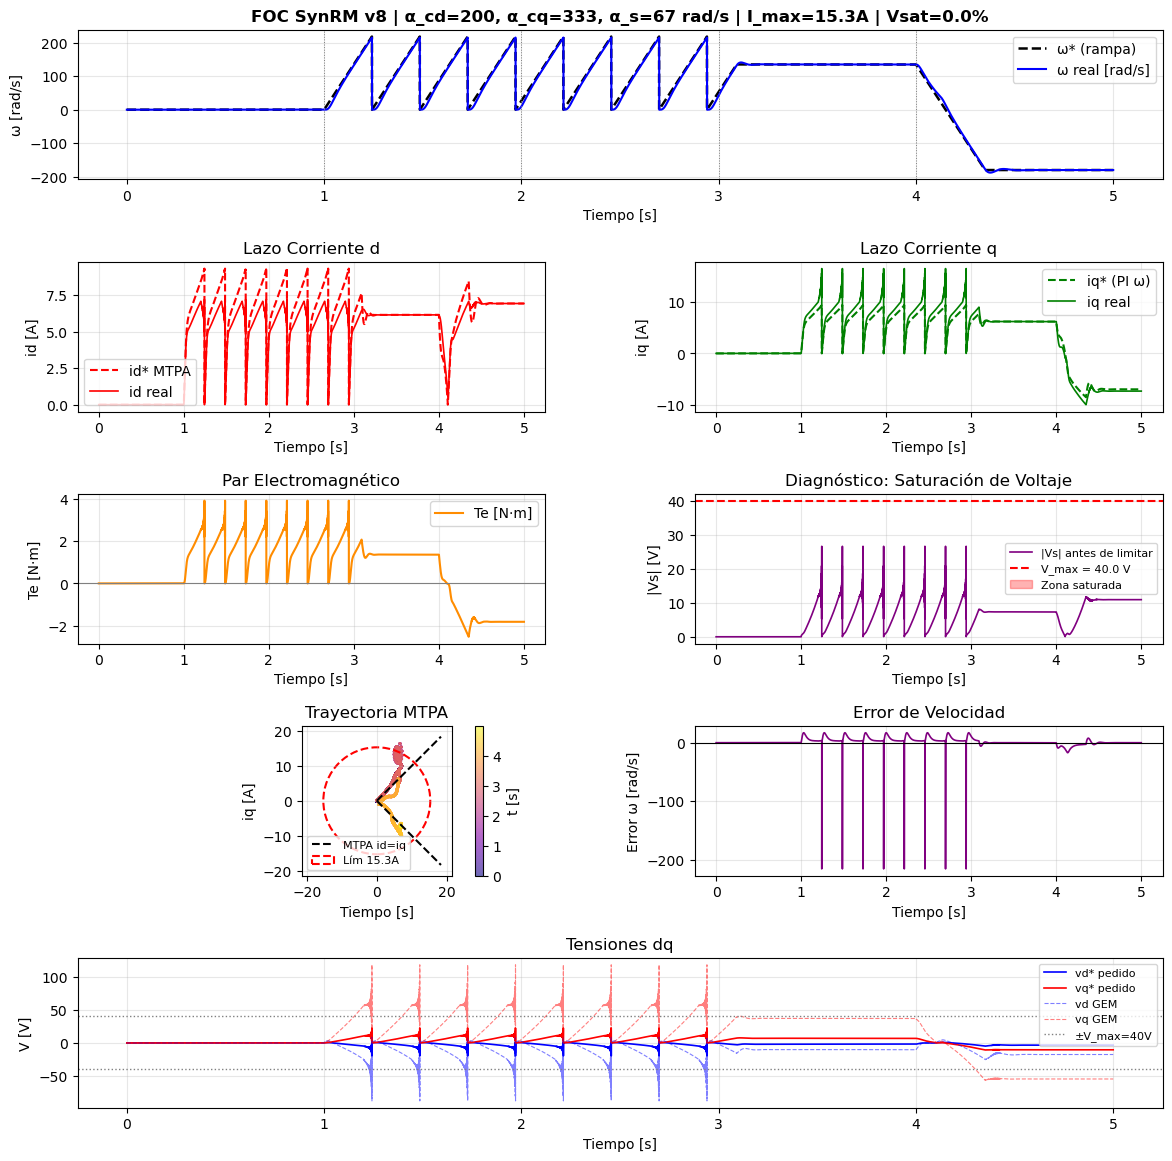

In [ ]:
H = {k: np.array(v) for k, v in hist.items()}
t = np.arange(len(H['omega'])) * tau
t_niveles = [n * 1 for n in range(1, 5)]

fig = plt.figure(figsize=(14, 14))
gs  = gridspec.GridSpec(5, 2, hspace=0.55, wspace=0.32)

# 1. Velocidad
ax1 = fig.add_subplot(gs[0, :])
#ax1.plot(t, H['omega_meta'], 'k:',  lw=1.0, alpha=0.5, label='ω meta')
ax1.plot(t, H['omega_ref'],  'k--', lw=1.8, label='ω* (rampa)')
ax1.plot(t, H['omega'],      'b',   lw=1.5, label='ω real [rad/s]')
for tv in t_niveles:
    ax1.axvline(tv, color='gray', lw=0.7, ls=':')
ax1.set_ylabel('ω [rad/s]'); ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_title(f'FOC SynRM v8 | α_cd={alpha_cd:.0f}, α_cq={alpha_cq:.0f}, α_s={alpha_s:.0f} rad/s | '
              f'I_max={I_max_mtpa:.1f}A | Vsat={pct_vsat:.1f}%', fontweight='bold')

# 2. Corriente d
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(t, H['id_ref'], 'r--', lw=1.5, label='id* MTPA')
ax2.plot(t, H['id'],     'r',   lw=1.2, label='id real')
ax2.set_ylabel('id [A]'); ax2.set_title('Lazo Corriente d')
ax2.legend(); ax2.grid(alpha=0.3)

# 3. Corriente q
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(t, H['iq_ref'], 'g--', lw=1.5, label='iq* (PI ω)')
ax3.plot(t, H['iq'],     'g',   lw=1.2, label='iq real')
ax3.set_ylabel('iq [A]'); ax3.set_title('Lazo Corriente q')
ax3.legend(); ax3.grid(alpha=0.3)

# 4. Par
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(t, H['torque'], color='darkorange', lw=1.5, label='Te [N·m]')
ax4.axhline(0, color='gray', lw=0.8)
ax4.set_ylabel('Te [N·m]'); ax4.set_title('Par Electromagnético')
ax4.legend(); ax4.grid(alpha=0.3)

# 5. Módulo de tensión — diagnóstico saturación
ax5 = fig.add_subplot(gs[2, 1])
ax5.plot(t, H['Vs'],  'purple', lw=1.2, label='|Vs| antes de limitar')
ax5.axhline(V_max, color='red', lw=1.5, ls='--', label=f'V_max = {V_max:.1f} V')
ax5.fill_between(t, V_max, H['Vs'],
                 where=H['Vs'] > V_max,
                 alpha=0.3, color='red', label='Zona saturada')
ax5.set_ylabel('|Vs| [V]'); ax5.set_title('Diagnóstico: Saturación de Voltaje')
ax5.legend(fontsize=8); ax5.grid(alpha=0.3)

# 6. Trayectoria MTPA
ax6 = fig.add_subplot(gs[3, 0])
sc  = ax6.scatter(H['id'], H['iq'], c=t, cmap='plasma', s=1.5, alpha=0.6)
I_v = np.linspace(0, I_max_mtpa*1.2, 100)
ax6.plot(I_v,  I_v, 'k--', lw=1.5, label='MTPA id=iq')
ax6.plot(I_v, -I_v, 'k--', lw=1.5)
ax6.add_patch(plt.Circle((0,0), I_max_mtpa, fill=False,
                          color='red', ls='--', lw=1.5, label=f'Lím {I_max_mtpa:.1f}A'))
ax6.set_xlabel('id [A]'); ax6.set_ylabel('iq [A]')
ax6.set_title('Trayectoria MTPA')
ax6.set_xlim(-I_max_mtpa*1.4, I_max_mtpa*1.4)
ax6.set_ylim(-I_max_mtpa*1.4, I_max_mtpa*1.4)
ax6.set_aspect('equal'); ax6.legend(fontsize=8); ax6.grid(alpha=0.3)
plt.colorbar(sc, ax=ax6, label='t [s]')

# 7. Error velocidad
ax7 = fig.add_subplot(gs[3, 1])
ax7.plot(t, H['omega_ref'] - H['omega'], color='purple', lw=1.2)
ax7.axhline(0, color='k', lw=0.8)
ax7.set_ylabel('Error ω [rad/s]'); ax7.set_title('Error de Velocidad')
ax7.grid(alpha=0.3)

# 8. Tensiones dq
ax8 = fig.add_subplot(gs[4, :])
ax8.plot(t, H['vd_req'], 'b',   lw=1.2, label='vd* pedido')
ax8.plot(t, H['vq_req'], 'r',   lw=1.2, label='vq* pedido')
ax8.plot(t, H['vd'],     'b--', lw=0.8, alpha=0.5, label='vd GEM')
ax8.plot(t, H['vq'],     'r--', lw=0.8, alpha=0.5, label='vq GEM')
ax8.axhline( V_max, color='gray', ls=':', lw=1)
ax8.axhline(-V_max, color='gray', ls=':', lw=1, label=f'±V_max={V_max:.0f}V')
ax8.set_ylabel('V [V]'); ax8.set_title('Tensiones dq')
ax8.legend(fontsize=8); ax8.grid(alpha=0.3)

for ax in [ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8]:
    ax.set_xlabel('Tiempo [s]')

plt.tight_layout()
plt.show()

METRICAS

In [ ]:
import numpy as np

def metricas_target(H, t, n, nombre, target, target_prev,
                    T_nivel, TASA_RAMPA, dt, V_max,
                    iq_min_mtpa=0.05, margen_frac=0.10):
    """
    Métricas por tramo adaptadas al target real.
    - Empieza a evaluar después de la rampa estimada + un pequeño margen.
    - Distingue error contra omega_ref (tracking) y contra target (regulación).
    - Usa tensión requerida (vd_req, vq_req) para medir saturación real pedida.
    """

    # Pasar todo a array por seguridad
    omega     = np.asarray(H['omega'])
    omega_ref = np.asarray(H['omega_ref'])     # referencia rampada
    omega_meta= np.asarray(H['omega_meta'])    # target ideal por tramo
    id_       = np.asarray(H['id'])
    iq        = np.asarray(H['iq'])
    id_ref    = np.asarray(H['id_ref'])
    iq_ref    = np.asarray(H['iq_ref'])
    torque    = np.asarray(H['torque'])
    vd_req    = np.asarray(H['vd_req'])
    vq_req    = np.asarray(H['vq_req'])

    # Intervalo completo del tramo n
    t_ini = n * T_nivel
    t_fin = (n + 1) * T_nivel

    # Tiempo estimado de rampa para ESTE salto
    delta_target = abs(target - target_prev)
    t_rampa_est = (delta_target / TASA_RAMPA) * dt if TASA_RAMPA > 0 else 0.0

    # Ventana de evaluación: después de la rampa + margen
    t_eval_ini = min(t_fin, t_ini + t_rampa_est + margen_frac * T_nivel)

    m_seg  = (t >= t_ini) & (t <= t_fin)       # tramo completo
    m_eval = (t >= t_eval_ini) & (t <= t_fin)  # ventana útil para métricas

    if not m_eval.any():
        print(f"\n{nombre}: sin muestras en ventana de evaluación.")
        return

    # Errores
    e_track = omega_ref[m_eval] - omega[m_eval]   # contra referencia rampada
    e_meta  = target - omega[m_eval]              # contra target ideal
    e_id    = id_ref[m_eval] - id_[m_eval]
    e_iq    = iq_ref[m_eval] - iq[m_eval]

    # Saturación pedida (antes del limitador)
    Vs_req = np.hypot(vd_req[m_eval], vq_req[m_eval])
    vsat = (Vs_req > V_max).mean() * 100

    # Overshoot respecto al target del tramo
    y_seg = omega[m_seg]
    if abs(target - target_prev) > 1e-9:
        if target > target_prev:
            pico = np.max(y_seg)
            overshoot = max(0.0, (pico - target) / abs(target - target_prev)) * 100
        else:
            valle = np.min(y_seg)
            overshoot = max(0.0, (target - valle) / abs(target - target_prev)) * 100
    else:
        overshoot = np.nan

    # Error estacionario aproximado al final del tramo
    e_final = np.mean(e_meta)

    print(f"\n{'='*64}")
    print(f"  {nombre}  [{t_ini:.3f}–{t_fin:.3f}s] | eval desde {t_eval_ini:.3f}s")
    print(f"{'='*64}")
    print(f"  target ω      = {target:.2f} rad/s")
    print(f"  ω_ref media   = {omega_ref[m_eval].mean():.2f} rad/s")
    print(f"  ω media       = {omega[m_eval].mean():.3f} rad/s")
    print(f"  Error track RMS (ω_ref-ω) = {np.sqrt(np.mean(e_track**2)):.4f} rad/s")
    print(f"  Error meta RMS  (target-ω)= {np.sqrt(np.mean(e_meta**2)):.4f} rad/s")
    print(f"  Error final medio         = {e_final:.4f} rad/s")
    print(f"  Error id RMS              = {np.sqrt(np.mean(e_id**2))*1000:.2f} mA")
    print(f"  Error iq RMS              = {np.sqrt(np.mean(e_iq**2))*1000:.2f} mA")
    print(f"  Te medio                  = {torque[m_eval].mean():.4f} N·m")
    print(f"  Vsat pedida               = {vsat:.1f}%  {'← saturado' if vsat > 10 else '✓ OK'}")

    if not np.isnan(overshoot):
        print(f"  Overshoot                 = {overshoot:.2f}%")

    # Ratio MTPA solo donde iq tiene sentido
    nz = np.abs(iq[m_eval]) > iq_min_mtpa
    if nz.any():
        ratio = np.mean(np.abs(id_[m_eval][nz] / iq[m_eval][nz]))
        print(f"  |id/iq|                   = {ratio:.4f}  (ideal lineal ≈ 1.0000)")

In [ ]:
nombres = ['Reposo', '50% nominal', '100% nominal', '30%', 'Inversión -40%']

target_prev = 0.0
for n, (nombre, target) in enumerate(zip(nombres, targets)):
    metricas_target(
        H, t, n, nombre, target, target_prev,
        T_nivel, TASA_RAMPA, dt, V_max
    )
    target_prev = target


  Reposo  [0.000–1.000s] | eval desde 0.100s
  target ω      = 0.00 rad/s
  ω_ref media   = 0.00 rad/s
  ω media       = 0.000 rad/s
  Error track RMS (ω_ref-ω) = 0.0009 rad/s
  Error meta RMS  (target-ω)= 0.0000 rad/s
  Error final medio         = 0.0000 rad/s
  Error id RMS              = 0.16 mA
  Error iq RMS              = 0.16 mA
  Te medio                  = 0.0000 N·m
  Vsat pedida               = 0.0%  ✓ OK

  50% nominal  [1.000–2.000s] | eval desde 1.350s
  target ω      = 225.15 rad/s
  ω_ref media   = 114.86 rad/s
  ω media       = 109.074 rad/s
  Error track RMS (ω_ref-ω) = 8.6694 rad/s
  Error meta RMS  (target-ω)= 134.2026 rad/s
  Error final medio         = 116.0732 rad/s
  Error id RMS              = 1428.24 mA
  Error iq RMS              = 1635.33 mA
  Te medio                  = 1.8030 N·m
  Vsat pedida               = 0.0%  ✓ OK
  Overshoot                 = 0.00%
  |id/iq|                   = 0.7203  (ideal lineal ≈ 1.0000)

  100% nominal  [2.000–3.000s] | eval 